# Audit — Qwen3-Embedding-0.6B → MiniLMv2-L6-H384

Notebook này chạy **mọi thực nghiệm của `docs/experiments_and_figures.md` trừ bảng chính** (Table 1 nằm ở
`notebooks/main_tables.ipynb`) trên cặp nhỏ nhất của bài, rồi dựng luôn bảng và hình từ output:

| Mục | Gì | Output |
|---|---|---|
| A | Đo lường mà phân tích dựa vào (không train): phổ teacher, energy vs angular distortion, ceiling STS, geometry của student tại init | Figure 1, Table A1 |
| E1 | Interface quyết định: một arm mỗi họ interface | Table 2, Figure 2 |
| E2 | Recipe ablation: bỏ từng design choice của §4 | Table 3, Figure 2 |
| E3 | Student thừa hưởng gì (post-hoc từ probe dump) | Figure 3, Table A2 |
| G | Gauge: null band, nội suy θ, rank-one | Figure A1, Table A3 |
| A5 | Sanity variants (tắt mặc định) | Table A5 |

Khuôn giống `main_tables.ipynb` (clone repo, cache teacher dùng chung, cùng cách chấm điểm), cộng ba
prerequisite của §0: corpus **dedup** khỏi mọi câu evaluation, một **probe set** cố định, và mỗi arm
lưu weight student mỗi epoch để encode probe set *sau* khi train (`probe_final.pt`, `train_summary.json`).
Mọi arm chạy ở **matched HP** (một lr / batch / epoch / λ / AdamW). Đặt `RUN_NAME` thành tên run cũ để
chạy tiếp: arm đã có final test bị bỏ qua, phân tích đọc lại từ đĩa.


In [1]:
# 1. Cấu hình thí nghiệm. Chỉnh các giá trị trong cell này trước khi chạy.
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo

REPO_URL = "https://github.com/duncan-nguyen/embedding-kd.git"

# Cặp của notebook này (cùng cấu trúc với PAIRS của main_tables.ipynb).
PAIRS = {
    "qwen3_0.6b_to_minilm_h384": {
        "teacher": "Qwen/Qwen3-Embedding-0.6B",
        "student": "nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base",
        "teacher_pooling": "last_token",
        "teacher_special_token": "Ġ",
        "emo_teacher_special_token": None,
        "min_vram_gib": 12,
        "note": "student nhỏ (384-d, 6 layer): cặp go/no-go của protocol",
    },
}
PAIR = "qwen3_0.6b_to_minilm_h384"
PAIR_CONFIG = PAIRS[PAIR]
TEACHER_MODEL = PAIR_CONFIG["teacher"]
STUDENT_MODEL = PAIR_CONFIG["student"]
TEACHER_POOLING = PAIR_CONFIG["teacher_pooling"]
STUDENT_POOLING = "cls"
# Encoder cùng cỡ train độc lập: mốc "một student tốt chia sẻ bao nhiêu với teacher này" (Figure 3).
REFERENCE_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
REFERENCE_POOLING = "mean"

DATASETS = {
    "100k": {"path": Path("data/train_set/train_100k.csv"), "build": None,
             "note": "102,361 dòng benchmark train"},
}
DATASET = "100k"
# §0.2: bỏ khỏi corpus mọi câu xuất hiện trong bất kỳ split evaluation nào. File dedup nằm cạnh file
# gốc, kèm manifest. Cache teacher khoá theo *nội dung* corpus nên corpus dedup có cache riêng.
DEDUP_CORPUS = True

# §0.3 matched HP: một bộ cho MỌI arm.
MATCHED_HP = {"batch_size": 64, "learning_rate": 5e-5, "epochs": 5, "lambda_ctr": 0.5, "max_length": 256}
EPOCHS = MATCHED_HP["epochs"]
# Seed train. Go/no-go: [42]. Claim: [42, 43, 44].
SEEDS = [42]
# Số draw Haar của arm ngẫu nhiên (random subspace, random gauge): độ tản giữa các draw là null band. >= 3.
DRAWS = 3
# lr của map học (learned_t2s / learned_s2t) theo bội số lr student: quét hai mức để baseline không bị strawman.
LEARNED_LR_SCALES = [1.0, 5.0]
# Trọng số term Gram của dòng "+ Gram" (Table 3): hai mức, cùng lý do.
GRAM_WEIGHTS = [1.0, 10.0]
# θ của nội suy gauge Q(θ) giữa Procrustes (0) và Haar (1) (Figure A1).
GAUGE_THETAS = [0.25, 0.5, 0.75]
# Bật/tắt từng nhóm. A5 = sanity variants của Table A5 (tắt mặc định).
GROUPS = {"E1": True, "E2": True, "G": True, "A5": False}

# Đánh giá: test ở cuối mỗi epoch (probe dump cho mọi thứ khác); không retrieval.
EVAL_ON_TEST_EACH_EPOCH = True
PAIR_THRESHOLD_SOURCE = "test" if EVAL_ON_TEST_EACH_EPOCH else "validation"
EVAL_EVERY = 0
EVAL_RETRIEVAL = False

# §0.1 probe set: 4096 câu corpus + mọi câu test của 9 task; không retrieval.
PROBE_SEED = 0
PROBE_CORPUS_SENTENCES = 4096
PROBE_EVAL_SPLITS = ("test_set",)
PROBE_CORE_EVAL = 4096          # phần "core": dump ở mọi epoch (probe đầy đủ chỉ dump epoch cuối)
PROBE_MAX_LENGTH = 256
PROBE_BATCH_SIZE = 256
# Checkpoint đầy đủ (có optimizer state) giữ lại sau khi dump: "all" | "last" | "none".
KEEP_FULL_CHECKPOINTS = "none"

# Phân tích.
K_SWEEP = (64, 128, 256, 384)             # rank của PCA-k / random-k (Figure 1)
KS = (1, 10, 50)                          # k của k-NN overlap (Table A2)
PROBE_SIZES = (1000, 4000, 16000)         # N của k-NN overlap (Table A2)
AGREEMENT_N = 4000                        # N cho Gram / CKA / Procrustes / kNN chính
GRAM_ROWS = 4096
N_PAIRS = 200_000                         # cặp ngẫu nhiên cho density (Figure 3)
SEED = 0
FIGURE3_BASES = ("pca__procrustes", "learned_t2s__lr1", "learned_s2t__lr1", "ours__no_teacher")
COLOUR_TASK = "emotion_test"              # subset có nhãn để tô màu Figure A2

NUM_WORKERS = 2
CUDA_VISIBLE_DEVICES = "0"
STOP_ON_ERROR = True
SAVE_TO_GOOGLE_DRIVE = False

RUN_STAMP = datetime.now(ZoneInfo("Asia/Ho_Chi_Minh")).strftime("%Y%m%d-%H%M%S")
DATASET_TAG = f"{DATASET}_dedup" if DEDUP_CORPUS else DATASET
RUN_NAME = f"audit_{PAIR}_{DATASET_TAG}_{RUN_STAMP}"
# Đặt RUN_NAME = "audit_..." của một run cũ để chạy tiếp / phân tích lại.

print(f"Pair: {PAIR} — {PAIR_CONFIG['note']}")
print(f"  teacher: {TEACHER_MODEL} (pooling={TEACHER_POOLING})")
print(f"  student: {STUDENT_MODEL} (pooling={STUDENT_POOLING}); reference: {REFERENCE_MODEL}")
print(f"Dataset: {DATASET_TAG}; matched HP: {MATCHED_HP}; seeds={SEEDS}; draws={DRAWS}")
print(f"Run name: {RUN_NAME}")


Pair: qwen3_0.6b_to_minilm_h384 — student nhỏ (384-d, 6 layer): cặp go/no-go của protocol
  teacher: Qwen/Qwen3-Embedding-0.6B (pooling=last_token)
  student: nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base (pooling=cls); reference: sentence-transformers/all-MiniLM-L6-v2
Dataset: 100k_dedup; matched HP: {'batch_size': 64, 'learning_rate': 5e-05, 'epochs': 5, 'lambda_ctr': 0.5, 'max_length': 256}; seeds=[42]; draws=3
Run name: audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415


In [2]:
# 2. Dùng repo hiện tại nếu notebook nằm trong repo; nếu không thì clone từ GitHub.
import subprocess
import sys

cwd = Path.cwd().resolve()
PROJECT_DIR = next(
    (p for p in (cwd, cwd.parent) if (p / "main.py").is_file() and (p / "distiller.py").is_file()), None
)
if PROJECT_DIR is None:
    clone_parent = Path("/content") if Path("/content").is_dir() else cwd
    PROJECT_DIR = clone_parent / "embedding-kd"
    if PROJECT_DIR.exists():
        assert (PROJECT_DIR / "main.py").is_file(), f"Thư mục đã tồn tại nhưng không phải repo hợp lệ: {PROJECT_DIR}"
        print(f"Reuse existing clone: {PROJECT_DIR}")
    else:
        subprocess.run(["git", "clone", REPO_URL, str(PROJECT_DIR)], check=True)

assert (PROJECT_DIR / ".git").exists(), f"Không phải Git clone: {PROJECT_DIR}"
head_before = subprocess.run(
    ["git", "-C", str(PROJECT_DIR), "rev-parse", "--short", "HEAD"],
    check=True, capture_output=True, text=True,
).stdout.strip()
subprocess.run(["git", "-C", str(PROJECT_DIR), "pull", "--ff-only"], check=True)
head_after = subprocess.run(
    ["git", "-C", str(PROJECT_DIR), "rev-parse", "--short", "HEAD"],
    check=True, capture_output=True, text=True,
).stdout.strip()
print(f"Git HEAD: {head_before} -> {head_after}")

assert (PROJECT_DIR / "requirements.txt").is_file()
print(f"Project directory: {PROJECT_DIR}")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_DIR / "requirements.txt")], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn"], check=False)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
print("Dependencies installed.")


Reuse existing clone: /content/embedding-kd
Project directory: /content/embedding-kd
Dependencies installed.


In [3]:
# 3. Nơi lưu output, kiểm tra GPU/data, dựng corpus dedup (§0.2).
import json
import os

import torch

from src.probe_set import deduplicate_corpus

try:
    from google.colab import drive as colab_drive
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True
if IN_COLAB and SAVE_TO_GOOGLE_DRIVE:
    colab_drive.mount("/content/drive")
    OUTPUT_BASE = Path("/content/drive/MyDrive/embedding-kd-runs")
else:
    OUTPUT_BASE = PROJECT_DIR / "runs"
RUN_ROOT = OUTPUT_BASE / RUN_NAME

for split in ("train_set", "val_set", "test_set"):
    split_dir = PROJECT_DIR / "data" / split
    assert split_dir.is_dir() and any(split_dir.glob("*.csv")), f"Thiếu dữ liệu evaluation: {split_dir}"

TRAIN_DATA_BY_DATASET = {}
DEDUP_MANIFESTS = {}
for key in (DATASET,):
    raw = PROJECT_DIR / DATASETS[key]["path"]
    assert raw.is_file(), f"Không tìm thấy corpus {key}: {raw}"
    if not DEDUP_CORPUS:
        TRAIN_DATA_BY_DATASET[key] = raw
        continue
    dedup = raw.with_name(f"{raw.stem}_dedup.csv")
    manifest_path = dedup.with_suffix(".manifest.json")
    if dedup.is_file() and manifest_path.is_file():
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        print(f"[dedup] dùng lại {dedup.name}: {manifest['rows_after']}/{manifest['rows_before']} dòng")
    else:
        manifest = deduplicate_corpus(raw, dedup, PROJECT_DIR, splits=("val_set", "test_set"))
        print(f"[dedup] {raw.name} -> {dedup.name}: bỏ {manifest['rows_removed']} / {manifest['rows_before']} dòng "
              f"trùng câu evaluation (theo task: {manifest['removed_by_task']})")
    TRAIN_DATA_BY_DATASET[key] = dedup
    DEDUP_MANIFESTS[key] = manifest
TRAIN_DATA = TRAIN_DATA_BY_DATASET[DATASET]

if not torch.cuda.is_available():
    raise RuntimeError(f"{TEACHER_MODEL} cần GPU; hãy bật GPU runtime rồi chạy lại.")
if hasattr(torch.cuda, "is_bf16_supported") and not torch.cuda.is_bf16_supported():
    raise RuntimeError("Config của repo tải teacher bằng BF16 nhưng GPU hiện tại không hỗ trợ BF16.")
if RUN_ROOT.is_dir():
    print(f"[note] RUN_ROOT đã tồn tại, sẽ chạy tiếp vào run cũ: {RUN_ROOT}")
RUN_ROOT.mkdir(parents=True, exist_ok=True)
print(f"PyTorch: {torch.__version__}; CUDA build: {torch.version.cuda}")
for index in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(index)
    print(f"  cuda:{index}: {props.name} ({props.total_memory / 2**30:.1f} GiB)")
train_rows = sum(1 for _ in TRAIN_DATA.open(encoding="utf-8")) - 1
print(f"Training data: {TRAIN_DATA} ({train_rows} dòng)")
print(f"Output root: {RUN_ROOT}")


[dedup] dùng lại train_100k_dedup.csv: 94537/102361 dòng
PyTorch: 2.11.0+cu128; CUDA build: 12.8
  cuda:0: NVIDIA A100-SXM4-80GB (79.3 GiB)
Training data: /content/embedding-kd/data/train_set/train_100k_dedup.csv (95044 dòng)
Output root: /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415


In [4]:
# 4. Probe set (§0.1) + teacher, student-init và reference encoder trên probe set — dựng một lần cho cả cặp.
#
# Probe set phụ thuộc vào corpus (4096 câu mẫu) và seed, không phụ thuộc vào arm hay run, nên nó nằm
# ngoài RUN_ROOT và được dùng lại bởi mọi run của cặp. Teacher trên probe set cũng vậy.
import re

import pandas as pd
import transformers
from transformers import AutoModel, AutoTokenizer

from src.probe_set import build_probe_set, probe_digest
from src.structural_audit import encode_texts, load_student

PROBE_DIR = OUTPUT_BASE / "probe" / PAIR
PROBE_DIR.mkdir(parents=True, exist_ok=True)
PROBE_PATH = PROBE_DIR / f"probe_{DATASET_TAG}_seed{PROBE_SEED}_noretrieval.csv"

if PROBE_PATH.is_file():
    PROBE = pd.read_csv(PROBE_PATH, keep_default_na=False)
    print(f"[probe] dùng lại {PROBE_PATH.name}: {len(PROBE)} câu")
else:
    PROBE = build_probe_set(PROJECT_DIR, TRAIN_DATA, n_corpus=PROBE_CORPUS_SENTENCES, n_docs_per_retrieval=0,
                            eval_splits=PROBE_EVAL_SPLITS, core_eval=PROBE_CORE_EVAL, core_retrieval=0, seed=PROBE_SEED)
    PROBE = PROBE[~PROBE["group"].str.startswith("retrieval")].reset_index(drop=True)
    PROBE["probe_id"] = range(len(PROBE))
    PROBE.to_csv(PROBE_PATH, index=False)
    print(f"[probe] dựng {PROBE_PATH.name}: {len(PROBE)} câu")
PROBE_DIGEST = probe_digest(PROBE)
PROBE_TEXTS = PROBE["text"].astype(str).tolist()
CORE_INDEX = PROBE.index[PROBE["core"].astype(bool)].to_numpy()
PROBE_CORE_TEXTS = [PROBE_TEXTS[i] for i in CORE_INDEX]
print(PROBE["group"].value_counts().to_string())
print(f"core: {len(CORE_INDEX)} câu; digest {PROBE_DIGEST}")


def slug(name):
    return re.sub(r"[^A-Za-z0-9]+", "-", name).strip("-").lower()


DEVICE = torch.device("cuda")
DTYPE_KW = "dtype" if int(transformers.__version__.split(".")[0]) >= 5 else "torch_dtype"

PROBE_TEACHER_PATH = PROBE_DIR / f"teacher_{slug(TEACHER_MODEL)}_{TEACHER_POOLING}_{PROBE_DIGEST}.pt"
if PROBE_TEACHER_PATH.is_file():
    print(f"[probe] teacher đã có: {PROBE_TEACHER_PATH.name}")
else:
    print(f"[probe] encode teacher {TEACHER_MODEL} trên {len(PROBE_TEXTS)} câu...")
    tok_teacher = AutoTokenizer.from_pretrained(TEACHER_MODEL, trust_remote_code=True)
    teacher = AutoModel.from_pretrained(TEACHER_MODEL, trust_remote_code=True, **{DTYPE_KW: torch.bfloat16}).to(DEVICE).eval()
    out = encode_texts(teacher, tok_teacher, PROBE_TEXTS, device=DEVICE, pooling=TEACHER_POOLING, batch_size=64,
                       max_length=PROBE_MAX_LENGTH, layers=False, amp=False, progress=True)
    torch.save({"embeddings": out["final"], "probe_digest": PROBE_DIGEST, "teacher_model_name": TEACHER_MODEL,
                "pooling_method": TEACHER_POOLING, "max_length": PROBE_MAX_LENGTH}, PROBE_TEACHER_PATH)
    del teacher
    torch.cuda.empty_cache()
    print(f"[probe] lưu {PROBE_TEACHER_PATH.name}: {tuple(out['final'].shape)}")


def encode_small_model(model_name, pooling, path, label):
    """Encoder nhỏ (student init / reference) trên probe set: lưu final layer, fp16."""
    if path.is_file():
        print(f"[probe] {label} đã có: {path.name}")
        return
    print(f"[probe] encode {label} {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = load_student(model_name, None, DEVICE)
    out = encode_texts(model, tokenizer, PROBE_TEXTS, device=DEVICE, pooling=pooling, batch_size=PROBE_BATCH_SIZE,
                       max_length=PROBE_MAX_LENGTH, layers=False, progress=True)
    torch.save({"final": out["final"].to(torch.float16), "probe_digest": PROBE_DIGEST, "model_name": model_name,
                "pooling": pooling}, path)
    del model
    torch.cuda.empty_cache()
    print(f"[probe] lưu {path.name}")


STUDENT_INIT_PATH = PROBE_DIR / f"student_init_{slug(STUDENT_MODEL)}_{STUDENT_POOLING}_{PROBE_DIGEST}.pt"
REFERENCE_PATH = PROBE_DIR / f"reference_{slug(REFERENCE_MODEL)}_{REFERENCE_POOLING}_{PROBE_DIGEST}.pt"
encode_small_model(STUDENT_MODEL, STUDENT_POOLING, STUDENT_INIT_PATH, "student init")
encode_small_model(REFERENCE_MODEL, REFERENCE_POOLING, REFERENCE_PATH, "reference encoder")


[probe] dùng lại probe_100k_dedup_seed0_noretrieval.csv: 42127 câu
group
eval      38031
corpus     4096
core: 8192 câu; digest 41b583a9a8b5d435
[probe] encode teacher Qwen/Qwen3-Embedding-0.6B trên 42127 câu...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.19GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  0%|          | 0/165 [00:00<?, ?it/s]

[probe] lưu reference_sentence-transformers-all-minilm-l6-v2_mean_41b583a9a8b5d435.pt


In [5]:
# 5. Arm registry: mọi arm của protocol, nhóm theo thí nghiệm, và command của từng arm.
#
# Flag của các arm target-map lấy từ scripts/run_target_map_ablation.py (một nguồn duy nhất). Command
# theo khuôn main_tables.ipynb, cộng: --seed, --save_every 1 (weight student mỗi epoch = nguồn của probe
# dump), --weights_dir, và matched HP (§0.3). Flag riêng của arm đi sau cùng để thắng mọi default.
import shlex

from scripts import run_target_map_ablation as ablation

CACHE_DIR = OUTPUT_BASE / "teacher_cache"
ARMS_ROOT = RUN_ROOT / "arms"
CACHED_TEACHER_METHODS = ("talas", "geoode", "rkd")


def build_command(name, method, train_data, seed, flags=()):
    arm_dir = ARMS_ROOT / name
    command = [
        sys.executable, str(PROJECT_DIR / "main.py"),
        "--method", method,
        "--train_data", str(train_data),
        "--student_model", STUDENT_MODEL,
        "--teacher_model", TEACHER_MODEL,
        "--teacher_pooling", TEACHER_POOLING,
        "--batch_size", str(MATCHED_HP["batch_size"]),
        "--epochs", str(MATCHED_HP["epochs"]),
        "--save_every", "1",
        "--lr", str(MATCHED_HP["learning_rate"]),
        "--max_length", str(MATCHED_HP["max_length"]),
        "--seed", str(seed),
        "--save_dir", str(arm_dir),
        "--weights_dir", str(arm_dir / "weights"),
        "--num_workers", str(NUM_WORKERS),
        "--pair_threshold_source", PAIR_THRESHOLD_SOURCE,
        "--eval_every", str(EVAL_EVERY),
        "--no_wandb",
    ]
    if EVAL_ON_TEST_EACH_EPOCH:
        command.append("--evaluate_test_each_epoch")
    if not EVAL_RETRIEVAL:
        command.append("--no_eval_retrieval")
    if method in CACHED_TEACHER_METHODS:
        command.extend(["--cache_dir", str(CACHE_DIR)])
    flags = list(flags)
    if method == "geoode" and "--lambda_ctr" not in flags:
        command.extend(["--lambda_ctr", str(MATCHED_HP["lambda_ctr"])])
    command.extend(flags)
    return command


def fixed_interface(subspace, gauge, draw=None, **extra):
    """Settings của một arm map đóng băng, theo đúng bảng arm của script."""
    settings = {**ablation.SUBSPACE_ARMS[subspace], **ablation.GAUGE_ARMS[gauge]}
    if subspace in ablation.STOCHASTIC_SUBSPACES:
        settings["projection_seed"] = int(draw or 0)
    if gauge == "random":
        settings["gauge_random_seed"] = int(draw or 0)
    settings.update(extra)
    return settings


OURS = fixed_interface("pca", "procrustes")
ARM_SPECS = []


def add(name, group, *, method="geoode", settings=None, flags=(), note="", needs=None):
    if not GROUPS.get(group, False):
        return
    ARM_SPECS.append({"name": name, "group": group, "method": method, "settings": settings,
                      "flags": list(flags), "dataset": DATASET, "note": note, "needs": needs})


# ---- E1: the interface decides (Table 2, Figure 2) — một arm mỗi họ interface -------------------
add("pca__procrustes", "E1", settings=OURS, note="ours: fixed principal subspace, một Procrustes R về student init")
for draw in range(DRAWS):
    add(f"random__none__d{draw}", "E1", settings=fixed_interface("random", "none", draw),
        note="fixed random subspace (Haar orthonormal) — ảnh Johnson–Lindenstrauss")
for scale in LEARNED_LR_SCALES:
    add(f"learned_t2s__lr{scale:g}", "E1",
        settings={"projection_type": "learned_t2s", "gauge_align": False, "learned_projector_lr_scale": scale},
        note="learned teacher->student W (sbert v5.5, EMO)")
for scale in LEARNED_LR_SCALES:
    add(f"learned_s2t__lr{scale:g}", "E1",
        settings={"projection_type": "learned_s2t", "gauge_align": False, "learned_projector_lr_scale": scale},
        note="learned student->teacher W (TALAS, LEAF)")
add("procrustes_per_batch", "E1", settings=fixed_interface("pca", "none", endpoint_loss="procrustes"),
    note="per-step orthogonal re-alignment (EdgePoint2 / Bhattarai): R_b giải lại mỗi batch")

# ---- E2: recipe ablation, bỏ từng design choice của §4 (Table 3) --------------------------------
add("ours__mse", "E2", settings=fixed_interface("pca", "procrustes", endpoint_loss="mse"),
    note="cosine -> MSE (sentence-transformers <= 5.4)")
add("ours__no_ctr", "E2", settings=OURS, flags=["--lambda_ctr", "0"], note="không InfoNCE")
for weight in GRAM_WEIGHTS:
    add(f"ours__gram_w{weight:g}", "E2", settings=fixed_interface("pca", "procrustes", lambda_gram=weight),
        note="+ term Gram (SP-KD/RKD) — control cho Prop. 3")
add("pca__none", "E2", settings=fixed_interface("pca", "none"), note="không gauge (PCA only)")
add("ours__refit", "E2", settings=fixed_interface("pca", "procrustes", gauge_refit_every=1),
    note="gauge refit mỗi epoch")
add("ours__no_teacher", "E2", settings=OURS, flags=["--lambda_end", "0"],
    note="không teacher: chỉ InfoNCE trong cùng harness (floor)")

# ---- G: gauge (Figure A1, Table A3) --------------------------------------------------------------
for draw in range(DRAWS):
    add(f"pca__random__d{draw}", "G", settings=fixed_interface("pca", "random", draw),
        note="PCA + xoay Haar cùng chi phí: null band")
for theta in GAUGE_THETAS:
    add(f"gauge_theta{theta:g}", "G",
        settings=fixed_interface("pca", "procrustes", gauge_rotation="interpolate", gauge_theta=theta, gauge_random_seed=0),
        note="Q(θ) = R exp(θ log(Rᵀ Q_haar)) — nội suy giữa Procrustes và Haar")
add("gauge_rank_one", "G", settings=fixed_interface("pca", "procrustes", gauge_rotation="rank_one"),
    note="Householder: chỉ khớp mean target lên mean student init")

# ---- A5: sanity variants (Table A5; tắt mặc định) ----------------------------------------------
add("random_gaussian__none__d0", "A5", settings=fixed_interface("random_gaussian", "none", 0),
    note="cùng subspace random, basis không orthonormal (JL thuần)")
add("pca_full__procrustes", "A5", settings=fixed_interface("pca_full", "procrustes"), note="PCA bỏ mean lúc áp map")
add("svd__procrustes", "A5", settings=fixed_interface("svd", "procrustes"), note="SVD không centre")
add("sbert__pca_mse", "A5", settings=fixed_interface("pca", "none", endpoint_loss="mse"), flags=["--lambda_ctr", "0"],
    note="sentence-transformers <= 5.4 recipe nguyên bản: PCA + MSE, không gauge, không InfoNCE (Adam nên reduction không quan trọng)")

ARM_PLAN = []
for spec in ARM_SPECS:
    for seed in SEEDS:
        arm = dict(spec, base=spec["name"], seed=seed)
        arm["name"] = f"{spec['name']}__s{seed}" if len(SEEDS) > 1 else spec["name"]
        arm["train_data"] = str(TRAIN_DATA_BY_DATASET[spec["dataset"]])
        ARM_PLAN.append(arm)

ARM_COMMANDS = {}
for arm in ARM_PLAN:
    if arm["needs"] is not None:
        continue
    flags = ablation.arm_flags(arm["settings"]) if arm["settings"] else []
    flags += arm["flags"]
    ARM_COMMANDS[arm["name"]] = build_command(arm["name"], arm["method"], arm["train_data"], arm["seed"], flags)

print(f"{len(ARM_PLAN)} arm trong plan -> {ARMS_ROOT}\n")
for arm in ARM_PLAN:
    if arm["needs"] is None:
        print(f"[{arm['group']}] {arm['name']}: {shlex.join(ARM_COMMANDS[arm['name']])}\n")
    else:
        print(f"[{arm['group']}] {arm['name']}: THIẾU CODE — {arm['needs']}\n")


23 arm trong plan -> /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/arms

[E1] pca__procrustes: /usr/bin/python3 /content/embedding-kd/main.py --method geoode --train_data /content/embedding-kd/data/train_set/train_100k_dedup.csv --student_model nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base --teacher_model Qwen/Qwen3-Embedding-0.6B --teacher_pooling last_token --batch_size 64 --epochs 5 --save_every 1 --lr 5e-05 --max_length 256 --seed 42 --save_dir /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/arms/pca__procrustes --weights_dir /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/arms/pca__procrustes/weights --num_workers 2 --pair_threshold_source test --eval_every 0 --no_wandb --evaluate_test_each_epoch --no_eval_retrieval --cache_dir /content/embedding-kd/runs/teacher_cache --lambda_ctr 0.5 --projection_type pca --pca_center_fit --no-pca_subtract_mean --gauge_align --

In [ ]:
# 6. Chạy tuần tự mọi arm; sau mỗi arm, dump probe (§0.1), ghi train_summary.json và cắt checkpoint nặng.
import shutil
import time

PROGRESS_EVERY_SEC = 30
PROGRESS_MAX_CHARS = 160


def has_final_test(metrics_path):
    """True chỉ với record cuối run: có "test", không có "train"."""
    if not metrics_path.is_file():
        return False
    with metrics_path.open(encoding="utf-8") as handle:
        return any(json.loads(line).get("test") and not json.loads(line).get("train") for line in handle if line.strip())


def stream_output(stream, log_handle):
    """Tee output: log đầy đủ ra file, notebook chỉ hiện dòng progress mới nhất."""
    buffer, last_progress, progress_shown = "", 0.0, False
    while True:
        chunk = stream.read(4096)
        if not chunk:
            break
        buffer += chunk
        parts = buffer.replace("\r\n", "\n").replace("\r", "\n").split("\n")
        buffer = parts.pop()
        for line in parts:
            log_handle.write(line + "\n")
            if "%|" in line:
                now = time.perf_counter()
                if now - last_progress >= PROGRESS_EVERY_SEC:
                    print("\r" + line[:PROGRESS_MAX_CHARS].ljust(PROGRESS_MAX_CHARS), end="", flush=True)
                    last_progress, progress_shown = now, True
            elif line.strip():
                if progress_shown:
                    print()
                    progress_shown = False
                print(line)
        log_handle.flush()
    if buffer:
        log_handle.write(buffer + "\n")
        if "%|" not in buffer:
            print(buffer)
    if progress_shown:
        print()


def read_records(path):
    if not path.is_file():
        return []
    with path.open(encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def write_train_summary(arm, arm_dir):
    """train_summary.json: loss theo epoch, điểm test cuối, metadata target map / map học."""
    records = read_records(arm_dir / "metrics.jsonl")
    train_epochs = [r["train"] for r in records if r.get("train")]
    final = next((r["test"] for r in records if r.get("test") and not r.get("train")), None)
    summary = {
        "arm": arm["name"], "base": arm["base"], "group": arm["group"], "method": arm["method"], "seed": arm["seed"],
        "dataset": arm["dataset"], "train_data": arm["train_data"], "settings": arm["settings"], "flags": arm["flags"],
        "note": arm["note"], "matched_hp": MATCHED_HP, "probe_digest": PROBE_DIGEST,
        "train_by_epoch": train_epochs, "final_train": train_epochs[-1] if train_epochs else None,
        "final_test_summary": final["summary"] if final else None,
        "final_test": {k: final[k] for k in ("classification", "pair", "sts") if k in final} if final else None,
    }
    projection_path = arm_dir / "teacher_projection.pt"
    if projection_path.is_file():
        saved = torch.load(projection_path, map_location="cpu", weights_only=False)
        summary["projection"] = {k: saved.get(k) for k in (
            "projection_type", "projection_seed", "pca_center_fit", "pca_subtract_mean", "explained_energy",
            "gauge_align", "gauge_rotation", "gauge_random_seed", "student_dim", "teacher_dim")}
        summary["gauge_stats"] = saved.get("gauge_stats")
    # Map học: W của từng epoch rút từ checkpoint (nhỏ) trước khi checkpoint bị cắt.
    maps = {}
    for path in sorted(arm_dir.glob("checkpoint_epoch_*.pt"), key=lambda p: int(p.stem.split("_")[-1])):
        state = (torch.load(path, map_location="cpu", weights_only=False).get("criterion_state_dict") or {})
        weight = next((v for k, v in state.items() if k.endswith("linear.weight")), None)
        if weight is None:
            break
        maps[int(path.stem.split("_")[-1])] = weight.float()
    if maps:
        torch.save({"epochs": sorted(maps), "weight": maps, "note": "nn.Linear weight [out, in]"}, arm_dir / "learned_map.pt")
        summary["learned_map"] = {"epochs": sorted(maps), "shape": list(next(iter(maps.values())).shape)}
    (arm_dir / "train_summary.json").write_text(json.dumps(summary, indent=2, default=float), encoding="utf-8")
    return summary


def dump_probe(arm, arm_dir, force=False):
    """probe_final.pt: epoch cuối trên cả probe set + mọi epoch trên core; kèm train_summary.json."""
    final_path = arm_dir / "probe_final.pt"
    if final_path.is_file() and (arm_dir / "train_summary.json").is_file() and not force:
        return "exists"
    weights_dir = arm_dir / "weights"
    epochs = sorted(int(p.stem.split("_")[-1]) for p in weights_dir.glob("student_epoch_*.pt"))
    if not epochs:
        raise FileNotFoundError(f"{arm['name']}: không có weights/student_epoch_*.pt để dump probe")
    init = torch.load(STUDENT_INIT_PATH, map_location="cpu", weights_only=False)
    assert init["probe_digest"] == PROBE_DIGEST
    core = {0: init["final"][CORE_INDEX]}
    final = None
    tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL)
    for epoch in epochs:
        model = load_student(STUDENT_MODEL, weights_dir / f"student_epoch_{epoch}.pt", DEVICE)
        if epoch == epochs[-1]:
            out = encode_texts(model, tokenizer, PROBE_TEXTS, device=DEVICE, pooling=STUDENT_POOLING,
                               batch_size=PROBE_BATCH_SIZE, max_length=PROBE_MAX_LENGTH, layers=False)
            final = out["final"].to(torch.float16)
            core[epoch] = final[CORE_INDEX]
        else:
            out = encode_texts(model, tokenizer, PROBE_CORE_TEXTS, device=DEVICE, pooling=STUDENT_POOLING,
                               batch_size=PROBE_BATCH_SIZE, max_length=PROBE_MAX_LENGTH, layers=False)
            core[epoch] = out["final"].to(torch.float16)
        del model
        torch.cuda.empty_cache()
        print(f"  [probe] {arm['name']} epoch {epoch}/{epochs[-1]} encoded", flush=True)
    torch.save({"probe_digest": PROBE_DIGEST, "student_model_name": STUDENT_MODEL, "pooling": STUDENT_POOLING,
                "max_length": PROBE_MAX_LENGTH, "arm": arm["name"], "final_epoch": epochs[-1], "final": final,
                "core_index": torch.from_numpy(CORE_INDEX), "core_epochs": sorted(core), "core": core}, final_path)
    write_train_summary(arm, arm_dir)
    return "dumped"


def prune_checkpoints(arm_dir):
    """Cắt checkpoint đầy đủ (optimizer state) theo KEEP_FULL_CHECKPOINTS; weights/ và probe luôn giữ."""
    if KEEP_FULL_CHECKPOINTS == "all":
        return 0
    checkpoints = sorted(arm_dir.glob("checkpoint_epoch_*.pt"), key=lambda p: int(p.stem.split("_")[-1]))
    doomed = list(checkpoints) if KEEP_FULL_CHECKPOINTS == "none" else checkpoints[:-1]
    doomed += [p for p in [arm_dir / "best_model.pt"] if p.is_file()]
    freed = sum(p.stat().st_size for p in doomed)
    for path in doomed:
        path.unlink()
    return freed


env = os.environ.copy()
env.update({"CUDA_VISIBLE_DEVICES": CUDA_VISIBLE_DEVICES, "TOKENIZERS_PARALLELISM": "false",
            "WANDB_MODE": "disabled", "TQDM_MININTERVAL": str(PROGRESS_EVERY_SEC)})
ARMS_ROOT.mkdir(parents=True, exist_ok=True)
(RUN_ROOT / "run_config.json").write_text(json.dumps({
    "run_name": RUN_NAME, "pair": PAIR, "pair_config": PAIR_CONFIG, "student_model": STUDENT_MODEL,
    "teacher_model": TEACHER_MODEL, "teacher_pooling": TEACHER_POOLING, "student_pooling": STUDENT_POOLING,
    "reference_model": REFERENCE_MODEL, "reference_path": str(REFERENCE_PATH),
    "dataset": DATASET, "dataset_tag": DATASET_TAG, "dedup": DEDUP_CORPUS, "train_data": str(TRAIN_DATA),
    "dedup_manifests": DEDUP_MANIFESTS, "matched_hp": MATCHED_HP, "seeds": SEEDS, "draws": DRAWS,
    "learned_lr_scales": LEARNED_LR_SCALES, "gram_weights": GRAM_WEIGHTS, "gauge_thetas": GAUGE_THETAS,
    "groups": GROUPS, "probe_path": str(PROBE_PATH), "probe_digest": PROBE_DIGEST,
    "probe_teacher_path": str(PROBE_TEACHER_PATH), "student_init_path": str(STUDENT_INIT_PATH),
    "cache_dir": str(CACHE_DIR), "arms_root": str(ARMS_ROOT), "arms": ARM_PLAN,
}, indent=2, default=str), encoding="utf-8")

run_status = []
for position, arm in enumerate(ARM_PLAN, start=1):
    name, arm_dir = arm["name"], ARMS_ROOT / arm["name"]
    if arm["needs"] is not None:
        print(f"[NEEDS CODE] {name}: {arm['needs']}")
        run_status.append({"arm": name, "status": "needs_code", "seconds": 0.0})
        continue
    metrics_path, log_path = arm_dir / "metrics.jsonl", ARMS_ROOT / f"{name}_train.log"
    if has_final_test(metrics_path):
        state = dump_probe(arm, arm_dir)
        prune_checkpoints(arm_dir)
        print(f"[SKIP] {name} đã có final test (probe: {state})")
        run_status.append({"arm": name, "status": "skipped_complete", "seconds": 0.0})
        continue
    if metrics_path.exists():
        raise RuntimeError(f"{name} có run dở dang tại {arm_dir}. Xoá thư mục đó hoặc dùng RUN_NAME mới.")
    print("\n" + "#" * 88)
    print(f"ARM {position}/{len(ARM_PLAN)} [{arm['group']}]: {name} — {arm['note']}")
    print(f"Log: {log_path}")
    print("#" * 88)
    started = time.perf_counter()
    with log_path.open("w", encoding="utf-8") as log_handle:
        process = subprocess.Popen(ARM_COMMANDS[name], cwd=PROJECT_DIR, env=env,
                                   stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        stream_output(process.stdout, log_handle)
        return_code = process.wait()
    elapsed = time.perf_counter() - started
    status = "complete" if return_code == 0 and has_final_test(metrics_path) else "failed"
    if status == "complete":
        dump_probe(arm, arm_dir)
        freed = prune_checkpoints(arm_dir)
        print(f"  [prune] giải phóng {freed / 2**30:.1f} GiB checkpoint")
    run_status.append({"arm": name, "status": status, "seconds": elapsed})
    print(f"[{status.upper()}] {name} in {elapsed / 60:.1f} minutes")
    if status == "failed" and STOP_ON_ERROR:
        raise RuntimeError(f"{name} failed; xem {log_path}")
pd.DataFrame(run_status).to_csv(RUN_ROOT / "run_status.csv", index=False)
print("\nDone:", RUN_ROOT)



########################################################################################
ARM 1/23 [E1]: pca__procrustes — ours: fixed principal subspace, một Procrustes R về student init
Log: /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/arms/pca__procrustes_train.log
########################################################################################
Configuration for GEOODE method:
  task_type                 : pair_cls
  max_length                : 256
  batch_size                : 64
  epochs                    : 5
  learning_rate             : 5e-05
  min_lr                    : 2e-06
  warmup_ratio              : 0.06
  w_task                    : 0.5
  alpha_dtw                 : 0.5
  w_cls                     : 1.0
  temperature               : 0.07
  student_model_name        : nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
  teacher_model_name        : Qwen/Qwen3-Embedding-0.6B
  teacher_dtype             : bfloat16
  pooling_

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [probe] pca__procrustes epoch 1/5 encoded


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [probe] gauge_rank_one epoch 4/5 encoded


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [probe] gauge_rank_one epoch 5/5 encoded
  [prune] giải phóng 1.5 GiB checkpoint
[COMPLETE] gauge_rank_one in 8.7 minutes

Done: /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415


In [ ]:
# 7. Nạp lại run cho phần phân tích (đọc từ đĩa, nên cũng dùng được với RUN_NAME cũ mà không train lại).
import math
import warnings

import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display

from src.cache_teacher import cache_filename, load_cached_embeddings
from src.probe_set import eval_pairs_in_probe
from src import structural_audit as sa

plt.style.use("seaborn-v0_8-whitegrid")
CONFIG = json.loads((RUN_ROOT / "run_config.json").read_text(encoding="utf-8"))
ANALYSIS_DIR = RUN_ROOT / "analysis"
ANALYSIS_DIR.mkdir(exist_ok=True)

teacher_payload = torch.load(CONFIG["probe_teacher_path"], map_location="cpu", weights_only=False)
assert teacher_payload["probe_digest"] == CONFIG["probe_digest"]
TEACHER = teacher_payload["embeddings"].float()          # [N, d_T] chưa normalize
TEACHER_UNIT = F.normalize(TEACHER, dim=-1)
STUDENT_INIT = torch.load(CONFIG["student_init_path"], map_location="cpu", weights_only=False)["final"].float()
REFERENCE = torch.load(CONFIG["reference_path"], map_location="cpu", weights_only=False)["final"].float()
N_PROBE, D_T = TEACHER.shape
D_S = STUDENT_INIT.shape[1]
print(f"Probe: {N_PROBE} câu (core {len(CORE_INDEX)}); d_T={D_T}, d_S={D_S}")

# Cache teacher của corpus train: fit PCA-k / random-k đúng như training. Thiếu thì fit trên probe.
cache_path = Path(CONFIG["cache_dir"]) / cache_filename(
    teacher_model_name=CONFIG["teacher_model"], pooling_method=CONFIG["teacher_pooling"],
    train_data_path=CONFIG["train_data"], max_length=int(CONFIG["matched_hp"]["max_length"]), normalize=True)
if cache_path.is_file():
    CACHE, _ = load_cached_embeddings(str(cache_path))
    CACHE = CACHE.float()
else:
    CACHE = None
    warnings.warn(f"Không thấy cache teacher {cache_path}; PCA-k / random-k sẽ fit trên teacher của probe set")
FIT_SOURCE = CACHE if CACHE is not None else TEACHER

ARMS = {}
for arm in CONFIG["arms"]:
    arm_dir = ARMS_ROOT / arm["name"]
    summary_path = arm_dir / "train_summary.json"
    entry = dict(arm, dir=arm_dir, done=summary_path.is_file())
    entry["summary"] = json.loads(summary_path.read_text(encoding="utf-8")) if entry["done"] else None
    ARMS[arm["name"]] = entry
DONE = [n for n, a in ARMS.items() if a["done"]]
BASES = list(dict.fromkeys(ARMS[n]["base"] for n in DONE))
SEEDS_OF = {base: [n for n in DONE if ARMS[n]["base"] == base] for base in BASES}
print(f"{len(DONE)}/{len(ARMS)} arm có probe dump: {BASES}")


def score_of(name, key="avg_all"):
    test = (ARMS[name]["summary"] or {}).get("final_test_summary") or {}
    return None if test.get(key) is None else 100.0 * float(test[key])


def final_train(name, key):
    return ((ARMS[name]["summary"] or {}).get("final_train") or {}).get(key)


_final_cache = {}


def load_final(name):
    """Embedding layer cuối trên cả probe set ở epoch cuối (float32)."""
    if name not in _final_cache:
        payload = torch.load(ARMS[name]["dir"] / "probe_final.pt", map_location="cpu", weights_only=False)
        assert payload["probe_digest"] == CONFIG["probe_digest"]
        _final_cache[name] = payload["final"].float()
    return _final_cache[name]


def learned_map(name):
    path = ARMS[name]["dir"] / "learned_map.pt"
    if not path.is_file():
        return None
    payload = torch.load(path, map_location="cpu", weights_only=False)
    return payload["weight"][payload["epochs"][-1]]


def arm_target(name):
    """Target của arm trên probe set: (tau [N, d_S] normalised | None, kind)."""
    projection_path = ARMS[name]["dir"] / "teacher_projection.pt"
    if projection_path.is_file():
        saved = sa.load_saved_projection(projection_path)
        if saved.get("projection") is not None:
            return sa.targets_from_saved(TEACHER, saved), "fixed"
        if saved.get("projection_type") == "learned_t2s":
            W = learned_map(name)
            return (F.normalize(TEACHER @ W.T, dim=-1) if W is not None else None), "learned_t2s"
        return None, "learned_s2t"
    return None, "none"


OURS_ARM = SEEDS_OF["pca__procrustes"][0] if "pca__procrustes" in SEEDS_OF else None
if OURS_ARM is not None:
    TARGET_OURS = arm_target(OURS_ARM)[0]
else:
    warnings.warn("Chưa có arm pca__procrustes: target tham chiếu là PCA fit lại trên cache")
    P, mean = sa.fit_variant(FIT_SOURCE, "pca", D_S)
    TARGET_OURS = sa.apply_map(TEACHER, P, mean=mean)

PAIR_TASKS = {stem: f"data/test_set/{stem}.csv" for stem in ("sick_test", "sts12_test", "stsb_test", "mrpc_test", "scitail_test", "wic_test")}
PROBE_PAIRS = eval_pairs_in_probe(PROJECT_DIR, PROBE, PAIR_TASKS)
STS_TASKS = [t for t, s in PROBE_PAIRS.items() if s["kind"] == "sts"]
for task, spec in PROBE_PAIRS.items():
    if spec["missing"]:
        print(f"[warn] {task}: {spec['missing']} cặp không nằm trong probe set")


def sts_ceiling(emb):
    scores = sa.pair_task_scores(emb, {t: PROBE_PAIRS[t] for t in STS_TASKS})
    return 100 * float(np.nanmean(list(scores.values()))), {t: 100 * v for t, v in scores.items()}


def by_base(frame, value_columns):
    grouped = frame.groupby("base", sort=False)[list(value_columns)].agg(["mean", "std", "count"])
    grouped.columns = [f"{c}_{s}" for c, s in grouped.columns]
    return grouped.reset_index()


def savefig(fig, name):
    path = ANALYSIS_DIR / name
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print(f"  -> {path}")


RNG = np.random.default_rng(SEED)
SUBSETS = {n: np.sort(RNG.choice(N_PROBE, size=min(int(n), N_PROBE), replace=False)) for n in PROBE_SIZES}
AGREE_IDX = SUBSETS[AGREEMENT_N] if AGREEMENT_N in SUBSETS else np.sort(RNG.choice(N_PROBE, size=min(AGREEMENT_N, N_PROBE), replace=False))


# Tên hiển thị cho hình/bảng (tên nội bộ kiểu pca__procrustes chỉ dùng trong code và tên thư mục).
import re
DISPLAY_NAME = {
    "pca__procrustes": "ours (PCA + Procrustes, frozen)",
    "pca__none": "PCA, no rotation",
    "pca__random": "PCA + random rotation",
    "random__none": "random subspace, frozen",
    "learned_t2s": "learned teacher\u2192student",
    "learned_s2t": "learned student\u2192teacher",
    "procrustes_per_batch": "per-batch Procrustes",
    "ours__mse": "ours, MSE instead of cosine",
    "ours__no_ctr": "ours, no InfoNCE",
    "ours__gram_w1": "ours + Gram term (w=1)",
    "ours__gram_w10": "ours + Gram term (w=10)",
    "ours__refit": "ours, gauge refit every epoch",
    "ours__no_teacher": "no teacher (SimCSE)",
    "gauge_rank_one": "rank-one rotation",
}


def display_name(base) -> str:
    """pca__random__d2 -> 'PCA + random rotation'; learned_t2s__lr5 -> 'learned teacher→student (projector lr ×5)'; gauge_theta0.5 -> 'Q(θ=0.5)'."""
    base = str(base)
    m = re.fullmatch(r"gauge_theta([0-9.]+)", base)
    if m:
        return f"Q(\u03b8={m.group(1)})"
    m = re.fullmatch(r"(learned_[ts]2[st])__lr(\d+)(?:__s\d+)?", base)
    if m:
        return DISPLAY_NAME[m.group(1)] + ("" if m.group(2) == "1" else f" (projector lr \u00d7{m.group(2)})")
    stem = re.sub(r"(__d\d+|__s\d+)+$", "", base)
    return DISPLAY_NAME.get(stem, base)


Probe: 42127 câu (core 8192); d_T=1024, d_S=384
Loading cached embeddings from: /content/embedding-kd/runs/teacher_cache/qwen-qwen3-embedding-0-6b__train_100k_dedup__last_token__5dc2a3003f5e.pt
Loaded embeddings: (94537, 1024)
23/23 arm có probe dump: ['pca__procrustes', 'random__none__d0', 'random__none__d1', 'random__none__d2', 'learned_t2s__lr1', 'learned_t2s__lr5', 'learned_s2t__lr1', 'learned_s2t__lr5', 'procrustes_per_batch', 'ours__mse', 'ours__no_ctr', 'ours__gram_w1', 'ours__gram_w10', 'pca__none', 'ours__refit', 'ours__no_teacher', 'pca__random__d0', 'pca__random__d1', 'pca__random__d2', 'gauge_theta0.25', 'gauge_theta0.5', 'gauge_theta0.75', 'gauge_rank_one']


teacher STS ceiling = 80.80


  -> /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/analysis/fig1_what_a_rank_dS_image_keeps.png


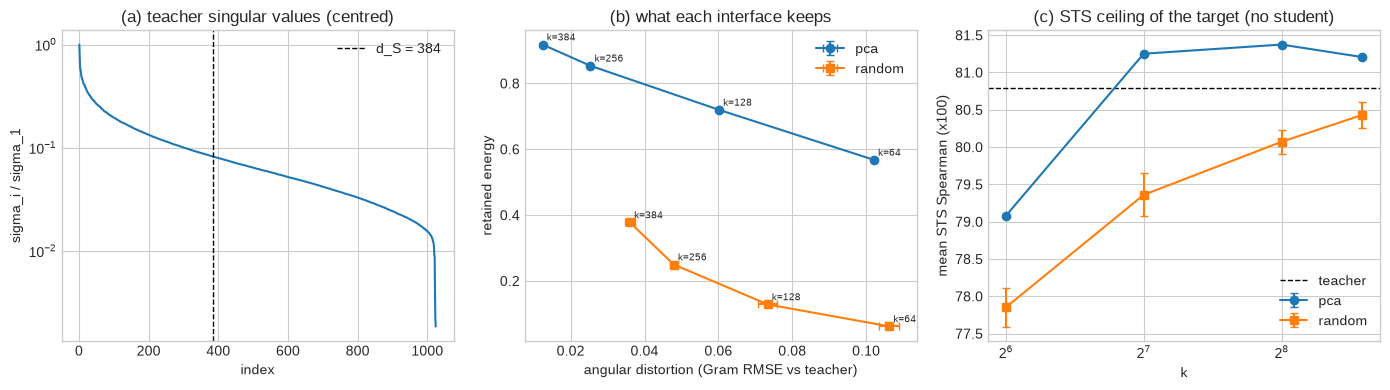

TABLE A1 — student geometry at initialisation


,model,anisotropy,effective_rank,twonn_id,cos_to_pca_target,cos_after_lstsq_map,gram_corr_vs_teacher,knn10_vs_teacher,participation_ratio,cos_init_after_R
0,nreimers/MiniLMv2-L6-H384-distilled-from-BERT-Base (init),0.9456,87.3588,16.3905,0.5988,0.9881,0.3841,0.1293,1.3638,0.6273
1,sentence-transformers/all-MiniLM-L6-v2 (trained),0.0265,318.9843,16.8052,-0.0018,0.7185,0.5280,0.4268,-,-


In [ ]:
# 8. A — đo lường mà phân tích dựa vào: Figure 1 (phổ · energy vs distortion · ceiling) và Table A1 (student tại init).
target_rows = []
for kind in ("pca", "random"):
    for k in K_SWEEP:
        draws = range(DRAWS) if kind == "random" else (0,)
        for draw in draws:
            P, mean = sa.fit_variant(FIT_SOURCE, kind, k, seed=draw)
            tau = sa.apply_map(TEACHER, P, mean=mean)
            ceiling, per_task = sts_ceiling(tau)
            target_rows.append({"kind": kind, "k": k, "draw": draw, "retained_energy": sa.retained_energy(FIT_SOURCE, P),
                                "distortion": sa.gram_rmse(tau[CORE_INDEX], TEACHER[CORE_INDEX], max_rows=GRAM_ROWS, seed=SEED),
                                "knn10": sa.knn_overlap(tau[AGREE_IDX], TEACHER[AGREE_IDX], 10),
                                "sts_ceiling": ceiling, **{f"sts_{t}": v for t, v in per_task.items()}})
teacher_ceiling, _ = sts_ceiling(TEACHER_UNIT)
targets_table = pd.DataFrame(target_rows)
targets_table.to_csv(ANALYSIS_DIR / "fig1_targets.csv", index=False)
agg = targets_table.groupby(["kind", "k"], sort=False)[["retained_energy", "distortion", "knn10", "sts_ceiling"]].agg(["mean", "std"])
print(f"teacher STS ceiling = {teacher_ceiling:.2f}")
display(agg.style.format(precision=4, na_rep="-"))

# Figure 1.
sigma = sa.singular_values(FIT_SOURCE[: min(len(FIT_SOURCE), 50000)], center=True)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].semilogy(np.arange(1, len(sigma) + 1), sigma / sigma[0])
axes[0].axvline(D_S, color="k", ls="--", lw=1, label=f"d_S = {D_S}")
axes[0].set(title="(a) teacher singular values (centred)", xlabel="index", ylabel="sigma_i / sigma_1")
axes[0].legend(frameon=False)
for kind, marker in (("pca", "o"), ("random", "s")):
    sub = agg.loc[kind]
    axes[1].errorbar(sub[("distortion", "mean")], sub[("retained_energy", "mean")], xerr=sub[("distortion", "std")].fillna(0),
                     yerr=sub[("retained_energy", "std")].fillna(0), marker=marker, capsize=3, label=kind)
    for k, r in sub.iterrows():
        axes[1].annotate(f"k={k}", (r[("distortion", "mean")], r[("retained_energy", "mean")]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    axes[2].errorbar(sub.index, sub[("sts_ceiling", "mean")], yerr=sub[("sts_ceiling", "std")].fillna(0), marker=marker, capsize=3, label=kind)
axes[1].set(title="(b) what each interface keeps", xlabel="angular distortion (Gram RMSE vs teacher)", ylabel="retained energy")
axes[1].legend(frameon=False)
axes[2].axhline(teacher_ceiling, color="k", ls="--", lw=1, label="teacher")
axes[2].set_xscale("log", base=2)
axes[2].set(title="(c) STS ceiling of the target (no student)", xlabel="k", ylabel="mean STS Spearman (x100)")
axes[2].legend(frameon=False)
fig.tight_layout(); savefig(fig, "fig1_what_a_rank_dS_image_keeps.png"); plt.show()

# Table A1 — geometry của student tại init, và của reference encoder (cùng cỡ, train độc lập).
def init_geometry(emb, label):
    core = emb[CORE_INDEX]
    unit = sa.unit(core)
    tau = TARGET_OURS[CORE_INDEX]
    # Shortcut của Prop. 4: least-squares W từ target vào state ban đầu — cosine nó đạt được ngay tại step 0.
    W = torch.linalg.lstsq(tau, unit).solution
    return {"model": label, "anisotropy": sa.anisotropy(core, n_pairs=N_PAIRS // 4, seed=SEED),
            "effective_rank": sa.effective_rank(core), "twonn_id": sa.twonn_intrinsic_dimension(core, seed=SEED),
            "cos_to_pca_target": float(sa.cosine_to_target(unit, tau).mean()),
            "cos_after_lstsq_map": float(sa.cosine_to_target(sa.unit(tau @ W), unit).mean()),
            "gram_corr_vs_teacher": sa.gram_correlation(core, TEACHER[CORE_INDEX], max_rows=GRAM_ROWS, seed=SEED),
            "knn10_vs_teacher": sa.knn_overlap(emb[AGREE_IDX], TEACHER[AGREE_IDX], 10)}

table_a1 = pd.DataFrame([init_geometry(STUDENT_INIT, f"{STUDENT_MODEL} (init)"), init_geometry(REFERENCE, f"{REFERENCE_MODEL} (trained)")])
if OURS_ARM is not None:
    stats = (ARMS[OURS_ARM]["summary"] or {}).get("gauge_stats") or {}
    table_a1.loc[0, "participation_ratio"] = stats.get("participation_ratio")
    table_a1.loc[0, "cos_init_after_R"] = stats.get("cos_after")
table_a1.to_csv(ANALYSIS_DIR / "tableA1_student_init_geometry.csv", index=False)
print("TABLE A1 — student geometry at initialisation")
display(table_a1.style.format(precision=4, na_rep="-"))


TABLE 2 — the interface decides (mean ± std over seeds)


,base,name,group,note,retained_energy_mean,retained_energy_std,retained_energy_count,distortion_mean,distortion_std,distortion_count,final_cos_gap_mean,final_cos_gap_std,final_cos_gap_count,final_loss_end_mean,final_loss_end_std,final_loss_end_count,effective_rank_mean,effective_rank_std,effective_rank_count,avg_all_mean,avg_all_std,avg_all_count
0,pca__procrustes,"ours (PCA + Procrustes, frozen)",E1,"ours: fixed principal subspace, một Procrustes R về student init",0.9180,-,1,0.0124,-,1,0.1949,-,1,0.1949,-,1,199.5002,-,1,76.2502,-,1
1,random__none__d0,"random subspace, frozen",E1,fixed random subspace (Haar orthonormal) — ảnh Johnson–Lindenstrauss,0.3807,-,1,0.0346,-,1,0.2276,-,1,0.2276,-,1,159.7133,-,1,75.5608,-,1
2,random__none__d1,"random subspace, frozen",E1,fixed random subspace (Haar orthonormal) — ảnh Johnson–Lindenstrauss,0.3773,-,1,0.0364,-,1,0.2295,-,1,0.2295,-,1,159.8616,-,1,75.6065,-,1
3,random__none__d2,"random subspace, frozen",E1,fixed random subspace (Haar orthonormal) — ảnh Johnson–Lindenstrauss,0.3746,-,1,0.0372,-,1,0.2326,-,1,0.2326,-,1,158.7201,-,1,75.5668,-,1
4,learned_t2s__lr1,learned teacher→student,E1,"learned teacher->student W (sbert v5.5, EMO)",-,-,0,0.1901,-,1,0.0626,-,1,0.0626,-,1,82.0209,-,1,71.8568,-,1
5,learned_t2s__lr5,learned teacher→student (projector lr ×5),E1,"learned teacher->student W (sbert v5.5, EMO)",-,-,0,0.1798,-,1,0.0528,-,1,0.0528,-,1,73.6219,-,1,70.9944,-,1
6,learned_s2t__lr1,learned student→teacher,E1,"learned student->teacher W (TALAS, LEAF)",-,-,0,-,-,0,0.2436,-,1,0.2436,-,1,166.2333,-,1,75.0016,-,1
7,learned_s2t__lr5,learned student→teacher (projector lr ×5),E1,"learned student->teacher W (TALAS, LEAF)",-,-,0,-,-,0,0.2179,-,1,0.2179,-,1,223.9310,-,1,75.7162,-,1
8,procrustes_per_batch,per-batch Procrustes,E1,per-step orthogonal re-alignment (EdgePoint2 / Bhattarai): R_b giải lại mỗi batch,0.9180,-,1,0.0124,-,1,1.0088,-,1,0.0249,-,1,289.5310,-,1,74.3224,-,1



TABLE 3 — recipe ablation, one design choice at a time


,base,name,group,note,retained_energy_mean,retained_energy_std,retained_energy_count,distortion_mean,distortion_std,distortion_count,final_cos_gap_mean,final_cos_gap_std,final_cos_gap_count,final_loss_end_mean,final_loss_end_std,final_loss_end_count,effective_rank_mean,effective_rank_std,effective_rank_count,avg_all_mean,avg_all_std,avg_all_count
0,pca__procrustes,"ours (PCA + Procrustes, frozen)",E1,"ours: fixed principal subspace, một Procrustes R về student init",0.9180,-,1,0.0124,-,1,0.1949,-,1,0.1949,-,1,199.5002,-,1,76.2502,-,1
9,ours__mse,"ours, MSE instead of cosine",E2,cosine -> MSE (sentence-transformers <= 5.4),0.9180,-,1,0.0124,-,1,0.5821,-,1,0.0191,-,1,186.2666,-,1,71.2846,-,1
10,ours__no_ctr,"ours, no InfoNCE",E2,không InfoNCE,0.9180,-,1,0.0124,-,1,0.1780,-,1,0.1780,-,1,204.5666,-,1,76.3978,-,1
11,ours__gram_w1,ours + Gram term (w=1),E2,+ term Gram (SP-KD/RKD) — control cho Prop. 3,0.9180,-,1,0.0124,-,1,0.2004,-,1,0.2004,-,1,203.3082,-,1,76.1058,-,1
12,ours__gram_w10,ours + Gram term (w=10),E2,+ term Gram (SP-KD/RKD) — control cho Prop. 3,0.9180,-,1,0.0124,-,1,0.2230,-,1,0.2230,-,1,211.5224,-,1,75.2811,-,1
13,pca__none,"PCA, no rotation",E2,không gauge (PCA only),0.9180,-,1,0.0124,-,1,0.2114,-,1,0.2114,-,1,170.6485,-,1,75.8901,-,1
14,ours__refit,"ours, gauge refit every epoch",E2,gauge refit mỗi epoch,0.9180,-,1,0.0124,-,1,0.1926,-,1,0.1926,-,1,207.4413,-,1,76.3598,-,1
15,ours__no_teacher,no teacher (SimCSE),E2,không teacher: chỉ InfoNCE trong cùng harness (floor),0.9180,-,1,0.0124,-,1,0.7228,-,1,0.7228,-,1,251.2982,-,1,68.3294,-,1


  -> /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/analysis/fig2_dissociation.png


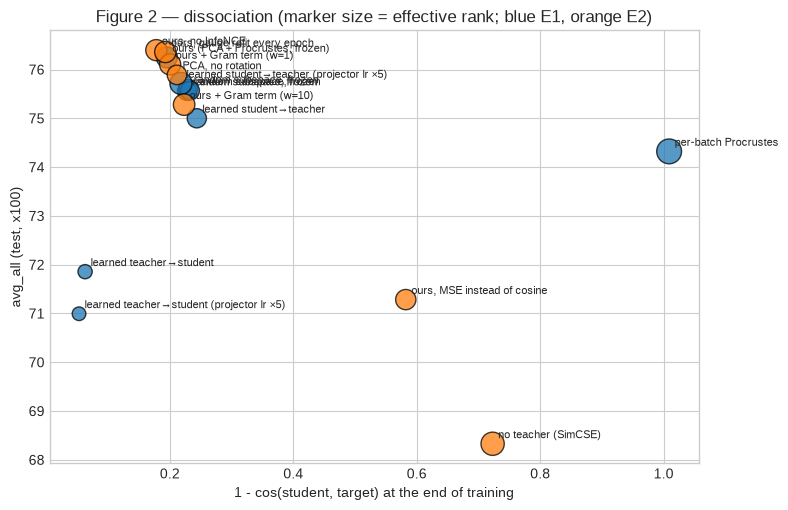

TABLE A3 — gauge (pca__random: mean ± std over draws = null band)


,name,theta_mean,theta_std,theta_count,avg_all_mean,avg_all_std,avg_all_count,loss_end_epoch1_mean,loss_end_epoch1_std,loss_end_epoch1_count,final_loss_end_mean,final_loss_end_std,final_loss_end_count,participation_ratio_mean,participation_ratio_std,participation_ratio_count,cos_init_after_mean,cos_init_after_std,cos_init_after_count
family,,,,,,,,,,,,,,,,,,,
pca__procrustes,"ours (PCA + Procrustes, frozen)",0.0000,-,1,76.2502,-,1,0.2951,-,1,0.1949,-,1,1.3638,-,1,0.6273,-,1
pca__none,"PCA, no rotation",-,-,0,75.8901,-,1,0.4332,-,1,0.2114,-,1,-,-,0,-,-,0
pca__random,PCA + random rotation,1.0000,0.0000,3,75.9091,0.0598,3,0.4212,0.0016,3,0.2121,0.0004,3,1.3638,0.0000,3,-0.0134,0.0274,3
gauge_theta0.25,Q(θ=0.25),0.2500,-,1,76.2420,-,1,0.3066,-,1,0.1968,-,1,1.3638,-,1,0.5598,-,1
gauge_theta0.5,Q(θ=0.5),0.5000,-,1,76.0839,-,1,0.3385,-,1,0.2013,-,1,1.3638,-,1,0.3815,-,1
gauge_theta0.75,Q(θ=0.75),0.7500,-,1,76.0222,-,1,0.3817,-,1,0.2070,-,1,1.3638,-,1,0.1548,-,1
gauge_rank_one,rank-one rotation,-,-,0,75.9041,-,1,0.3787,-,1,0.2083,-,1,1.3638,-,1,0.5359,-,1


  -> /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/analysis/figA1_gauge_interpolation.png


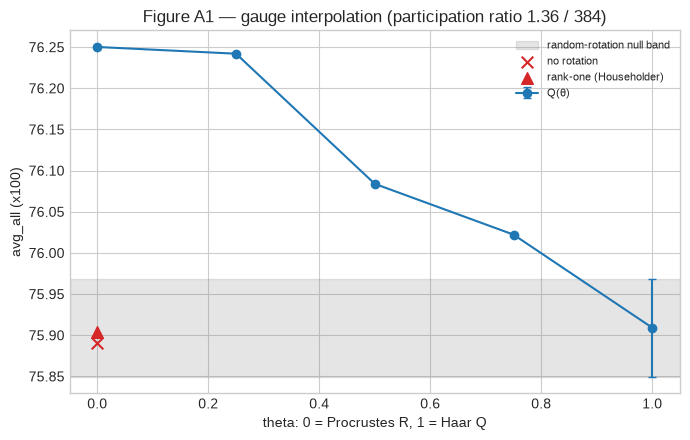

In [ ]:
# 9. E1 + E2 + G — Table 2 (interface families), Table 3 (recipe ablation), Figure 2 (dissociation), Table A3 / Figure A1 (gauge).
rows = []
for name in DONE:
    arm = ARMS[name]
    final = load_final(name)
    tau, kind = arm_target(name)
    projection = (arm["summary"] or {}).get("projection") or {}
    cos_final = final_train(name, "cos_final")
    rows.append({"arm": name, "base": arm["base"], "group": arm["group"], "seed": arm["seed"], "kind": kind,
                 "retained_energy": projection.get("explained_energy"),
                 "distortion": (sa.gram_rmse(tau[CORE_INDEX], TEACHER[CORE_INDEX], max_rows=GRAM_ROWS, seed=SEED) if tau is not None else np.nan),
                 "final_loss_end": final_train(name, "loss_end"),
                 "final_cos_gap": (1.0 - float(cos_final)) if cos_final is not None else np.nan,   # 1 - cos(z, tau), so sánh được giữa mọi arm
                 "effective_rank": sa.effective_rank(final[CORE_INDEX]),
                 "avg_all": score_of(name), "avg_iod": score_of(name, "avg_iod"), "avg_ood": score_of(name, "avg_ood")})
arm_table = pd.DataFrame(rows)
arm_table.to_csv(ANALYSIS_DIR / "arm_metrics.csv", index=False)
COLUMNS = ["retained_energy", "distortion", "final_cos_gap", "final_loss_end", "effective_rank", "avg_all"]
summary = by_base(arm_table, COLUMNS)
summary.insert(1, "name", [display_name(b) for b in summary["base"]])
summary.insert(2, "group", [ARMS[SEEDS_OF[b][0]]["group"] for b in summary["base"]])
summary.insert(3, "note", [ARMS[SEEDS_OF[b][0]]["note"] for b in summary["base"]])

table2 = summary[summary["group"] == "E1"]
table3 = summary[(summary["group"] == "E2") | (summary["base"] == "pca__procrustes")]
table2.to_csv(ANALYSIS_DIR / "table2_interface_families.csv", index=False)
table3.to_csv(ANALYSIS_DIR / "table3_recipe_ablation.csv", index=False)
print("TABLE 2 — the interface decides (mean ± std over seeds)")
display(table2.style.format(precision=4, na_rep="-"))
print("\nTABLE 3 — recipe ablation, one design choice at a time")
display(table3.style.format(precision=4, na_rep="-"))
if "A5" in set(summary["group"]):
    summary[summary["group"] == "A5"].to_csv(ANALYSIS_DIR / "tableA5_sanity.csv", index=False)

# Figure 2 — dissociation: x = 1 - cos(z, tau) cuối train, y = điểm, size = effective rank.
c = summary[summary["group"].isin(["E1", "E2"]) & summary["final_cos_gap_mean"].notna() & summary["avg_all_mean"].notna()]
fig, ax = plt.subplots(figsize=(8, 5.2))
size = 20 + 300 * (c["effective_rank_mean"] / max(c["effective_rank_mean"].max(), 1e-9))
colours = c["group"].map({"E1": "C0", "E2": "C1"})
ax.scatter(c["final_cos_gap_mean"], c["avg_all_mean"], s=size, c=colours, alpha=0.75, edgecolor="k")
ax.errorbar(c["final_cos_gap_mean"], c["avg_all_mean"], xerr=c["final_cos_gap_std"].fillna(0), yerr=c["avg_all_std"].fillna(0), fmt="none", ecolor="gray", lw=0.8)
for _, r in c.iterrows():
    ax.annotate(display_name(r["base"]), (r["final_cos_gap_mean"], r["avg_all_mean"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set(title="Figure 2 — dissociation (marker size = effective rank; blue E1, orange E2)",
       xlabel="1 - cos(student, target) at the end of training", ylabel="avg_all (test, x100)")
fig.tight_layout(); savefig(fig, "fig2_dissociation.png"); plt.show()

# Table A3 / Figure A1 — gauge.
def theta_of(base):
    if base == "pca__procrustes":
        return 0.0
    if base.startswith("pca__random"):
        return 1.0
    if base.startswith("gauge_theta"):
        return float(base.replace("gauge_theta", ""))
    return None

gauge_rows = []
for base in BASES:
    if not (base in ("pca__procrustes", "pca__none", "gauge_rank_one") or base.startswith(("pca__random", "gauge_theta"))):
        continue
    for name in SEEDS_OF[base]:
        s = ARMS[name]["summary"] or {}
        stats, by_epoch = s.get("gauge_stats") or {}, s.get("train_by_epoch") or []
        gauge_rows.append({"base": base, "arm": name, "theta": theta_of(base), "avg_all": score_of(name),
                           "loss_end_epoch1": (by_epoch[0] or {}).get("loss_end") if by_epoch else None,
                           "final_loss_end": final_train(name, "loss_end"),
                           "participation_ratio": stats.get("participation_ratio"),
                           "cos_init_after": stats.get("cos_after"), "cos_procrustes_would": stats.get("cos_procrustes")})
gauge = pd.DataFrame(gauge_rows)
if not gauge.empty:
    gauge.to_csv(ANALYSIS_DIR / "tableA3_gauge_by_arm.csv", index=False)
    gauge["family"] = gauge["base"].str.replace(r"__d\d+$", "", regex=True)
    table_a3 = gauge.groupby("family", sort=False)[["theta", "avg_all", "loss_end_epoch1", "final_loss_end", "participation_ratio", "cos_init_after"]].agg(["mean", "std", "count"])
    table_a3.columns = [f"{c}_{s}" for c, s in table_a3.columns]
    table_a3.insert(0, "name", [display_name(f) for f in table_a3.index])
    table_a3.to_csv(ANALYSIS_DIR / "tableA3_gauge.csv")
    print("TABLE A3 — gauge (pca__random: mean ± std over draws = null band)")
    display(table_a3.style.format(precision=4, na_rep="-"))
    pr = gauge["participation_ratio"].dropna()
    with_theta = gauge[gauge["theta"].notna()]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    agg = with_theta.groupby("theta")["avg_all"].agg(["mean", "std"])
    ax.errorbar(agg.index, agg["mean"], yerr=agg["std"].fillna(0), marker="o", capsize=3, label="Q(θ)")
    rand = gauge[gauge["base"].str.startswith("pca__random")]["avg_all"].dropna()
    if len(rand) > 1:
        ax.axhspan(rand.mean() - rand.std(), rand.mean() + rand.std(), color="gray", alpha=0.2, label="random-rotation null band")
    for base, marker, label in (("pca__none", "x", "no rotation"), ("gauge_rank_one", "^", "rank-one (Householder)")):
        if base in SEEDS_OF:
            ax.scatter([0.0], [gauge[gauge["base"] == base]["avg_all"].mean()], marker=marker, s=70, color="C3", label=label, zorder=5)
    ax.set(title=f"Figure A1 — gauge interpolation (participation ratio {pr.iloc[0]:.2f} / {D_S})" if not pr.empty else "Figure A1",
           xlabel="theta: 0 = Procrustes R, 1 = Haar Q", ylabel="avg_all (x100)")
    ax.legend(fontsize=8, frameon=False)
    fig.tight_layout(); savefig(fig, "figA1_gauge_interpolation.png"); plt.show()


/tmp/ipykernel_6717/1629291137.py:23: RuntimeWarning: invalid value encountered in scalar divide
  row["residual_top1_share"] = float(spectrum["residual"][0] ** 2 / (spectrum["residual"] ** 2).sum())


TABLE A2 — geometry inheritance (teacher agreement; residual vs the arm's own target)


,label,base,seed,pair_cos_spearman,gram_corr,linear_cka,procrustes,knn@10_N1000,knn@1_N4000,knn@10_N4000,knn@50_N4000,knn@10_N16000,cos_to_target,residual_effective_rank,residual_top1_share
0,ceiling: PCA target vs teacher,-,-,0.9976,0.9989,0.9836,0.0960,0.9303,0.9150,0.9302,0.9412,0.9286,1.0000,1.0000,-
1,reference: sentence-transformers/all-MiniLM-L6-v2,-,-,0.4399,0.4958,0.6003,0.7519,0.4157,0.4017,0.4268,0.4258,0.4461,-,-,-
2,student init,-,-,0.3872,0.3629,0.4589,1.0239,0.1579,0.1120,0.1293,0.1785,0.1180,0.5988,330.9116,0.2667
3,"ours (PCA + Procrustes, frozen)",pca__procrustes,42,0.7047,0.7174,0.8204,0.5587,0.4582,0.3660,0.4281,0.4845,0.4107,0.8154,361.7889,0.0349
4,"random subspace, frozen",random__none__d0,42,0.6488,0.6664,0.7819,0.6340,0.4355,0.3495,0.4035,0.4602,0.3893,0.7850,350.5287,0.0356
5,"random subspace, frozen",random__none__d1,42,0.6577,0.6756,0.7763,0.6349,0.4357,0.3483,0.4036,0.4622,0.3900,0.7828,350.5899,0.0357
6,"random subspace, frozen",random__none__d2,42,0.6433,0.6620,0.7817,0.6370,0.4342,0.3428,0.4067,0.4602,0.3900,0.7806,350.5500,0.0355
7,learned teacher→student,learned_t2s__lr1,42,0.4054,0.4290,0.6980,0.8813,0.3207,0.2262,0.2728,0.3431,0.2577,0.9492,245.0731,0.0591
8,learned teacher→student (projector lr ×5),learned_t2s__lr5,42,0.3885,0.4207,0.6669,0.9307,0.3037,0.2087,0.2539,0.3243,0.2398,0.9585,180.6487,0.0627
9,learned student→teacher,learned_s2t__lr1,42,0.4269,0.4949,0.7482,0.6550,0.4088,0.3268,0.3815,0.4336,0.3653,-,-,-


  -> /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/analysis/fig3_geometry_inheritance.png


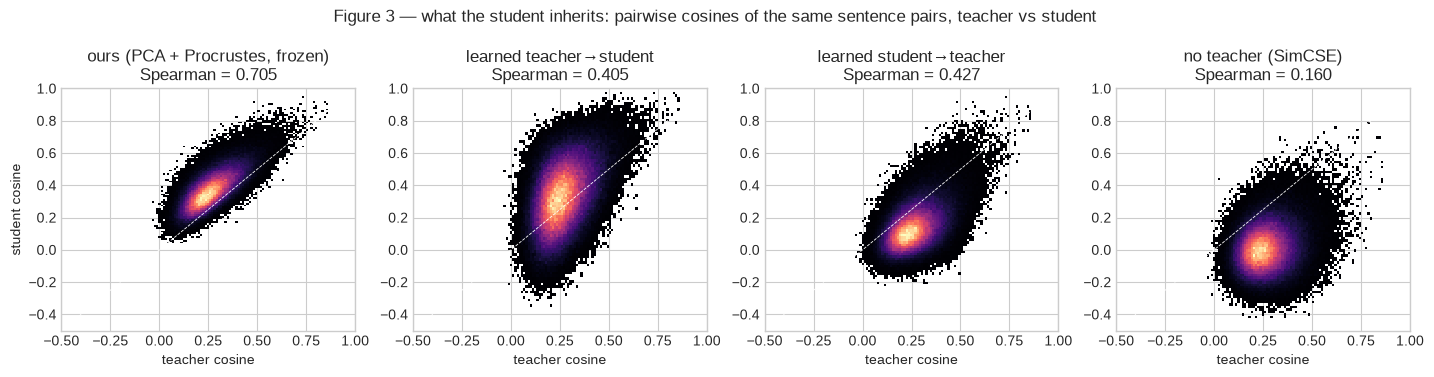

  -> /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/analysis/fig3b_student_spectrum.png


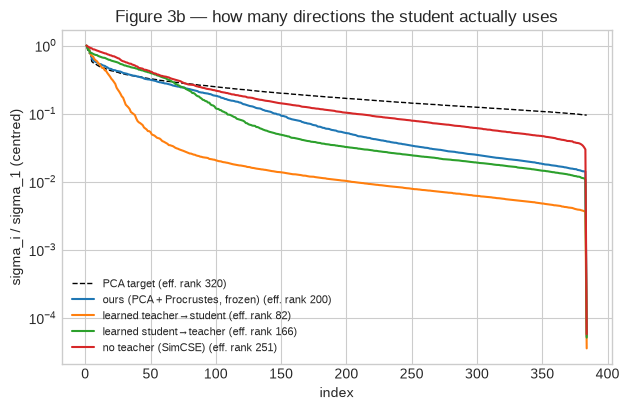

In [ ]:
# 10. E3 — student thừa hưởng gì: Figure 3 (density cosine từng cặp · phổ residual) và Table A2 (agreement metrics).
pairs = sa.random_pairs(len(CORE_INDEX), N_PAIRS, seed=SEED)
teacher_cos = sa.pairwise_cosines(TEACHER[CORE_INDEX], pairs)
teacher_nn = {n: sa.knn_indices(TEACHER[idx], max(KS)) for n, idx in SUBSETS.items()}


def agreement(emb, tau, label, base="-", seed="-"):
    """Rung 2–4 của thang đo (student vs teacher ĐẦY ĐỦ) + residual so với target của chính arm."""
    idx = AGREE_IDX
    row = {"label": label, "base": base, "seed": seed,
           "pair_cos_spearman": float(pd.Series(sa.pairwise_cosines(emb[CORE_INDEX], pairs)).corr(pd.Series(teacher_cos), method="spearman")),
           "gram_corr": sa.gram_correlation(emb[idx], TEACHER[idx], max_rows=GRAM_ROWS, seed=SEED),
           "linear_cka": sa.linear_cka(emb[idx], TEACHER[idx]), "procrustes": sa.procrustes_distance(emb[idx], TEACHER[idx])}
    for n, sub in SUBSETS.items():
        na = sa.knn_indices(emb[sub], max(KS))
        for k in KS:
            if n == AGREEMENT_N or k == 10:
                row[f"knn@{k}_N{n}"] = sa.knn_overlap(emb[sub], TEACHER[sub], k, neighbours_a=na, neighbours_b=teacher_nn[n])
    if tau is not None:
        spectrum = sa.residual_spectrum(emb[CORE_INDEX], tau[CORE_INDEX])
        row["cos_to_target"] = float(sa.cosine_to_target(emb[CORE_INDEX], tau[CORE_INDEX]).mean())
        row["residual_effective_rank"] = sa.effective_rank(sa.unit(emb[CORE_INDEX]) - sa.unit(tau[CORE_INDEX]))
        row["residual_top1_share"] = float(spectrum["residual"][0] ** 2 / (spectrum["residual"] ** 2).sum())
    return row


rows = [agreement(TARGET_OURS, TARGET_OURS, "ceiling: PCA target vs teacher"),
        agreement(REFERENCE, None, f"reference: {REFERENCE_MODEL}"),
        agreement(STUDENT_INIT, TARGET_OURS, "student init")]
for name in DONE:
    if ARMS[name]["group"] not in ("E1", "E2"):
        continue
    tau, kind = arm_target(name)
    rows.append(agreement(load_final(name), tau if kind in ("fixed", "learned_t2s") else None, display_name(ARMS[name]["base"]), ARMS[name]["base"], ARMS[name]["seed"]))
table_a2 = pd.DataFrame(rows)
table_a2.to_csv(ANALYSIS_DIR / "tableA2_inheritance_by_arm.csv", index=False)
print("TABLE A2 — geometry inheritance (teacher agreement; residual vs the arm's own target)")
display(table_a2.style.format(precision=4, na_rep="-"))

# Figure 3 — một hàng: cosine từng cặp của teacher (x) vs của student (y) trên cùng N_PAIRS cặp ngẫu nhiên.
# Đọc: bám đường chéo = thừa kế cấu trúc cặp; dải dọc rộng = student cosine không còn được teacher cosine quyết định.
panels = [b for b in FIGURE3_BASES if b in SEEDS_OF]
fig, axes = plt.subplots(1, max(len(panels), 1), figsize=(3.6 * max(len(panels), 1), 3.8), squeeze=False)
for col, base in enumerate(panels):
    name = SEEDS_OF[base][0]
    emb = load_final(name)
    student_cos = sa.pairwise_cosines(emb[CORE_INDEX], pairs)
    rho = float(pd.Series(student_cos).corr(pd.Series(teacher_cos), method="spearman"))
    ax = axes[0, col]
    ax.hist2d(teacher_cos, student_cos, bins=80, cmap="magma", cmin=1)
    ax.plot([-1, 1], [-1, 1], color="w", lw=0.6, ls="--")
    ax.set(title=f"{display_name(base)}\nSpearman = {rho:.3f}", xlabel="teacher cosine", ylabel="student cosine" if col == 0 else "",
           xlim=(-0.5, 1), ylim=(-0.5, 1))
fig.suptitle("Figure 3 — what the student inherits: pairwise cosines of the same sentence pairs, teacher vs student")
fig.tight_layout(); savefig(fig, "fig3_geometry_inheritance.png"); plt.show()

# Figure 3b (tuỳ chọn, để cân nhắc thay cho hàng residual cũ): phổ singular value của CHÍNH embedding student (centred),
# so với phổ PCA target — có nghĩa với mọi arm (kể cả s→t và no_teacher); ghi kèm effective rank = cái Figure 2 mã hoá bằng cỡ marker.
fig, ax = plt.subplots(figsize=(6.4, 4.2))
target_sigma = sa.singular_values(TARGET_OURS[CORE_INDEX], center=True)
ax.semilogy(np.arange(1, len(target_sigma) + 1), target_sigma / target_sigma[0], color="k", ls="--", lw=1,
            label=f"PCA target (eff. rank {sa.effective_rank(TARGET_OURS[CORE_INDEX]):.0f})")
for i, base in enumerate(panels):
    emb = load_final(SEEDS_OF[base][0])[CORE_INDEX]
    sigma = sa.singular_values(emb, center=True)
    ax.semilogy(np.arange(1, len(sigma) + 1), sigma / sigma[0], color=f"C{i}", label=f"{display_name(base)} (eff. rank {sa.effective_rank(emb):.0f})")
ax.set(title="Figure 3b — how many directions the student actually uses", xlabel="index", ylabel="sigma_i / sigma_1 (centred)")
ax.legend(fontsize=8, frameon=False)
fig.tight_layout(); savefig(fig, "fig3b_student_spectrum.png"); plt.show()


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  -> /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415/analysis/figA2_geometry_inheritance_visual.png


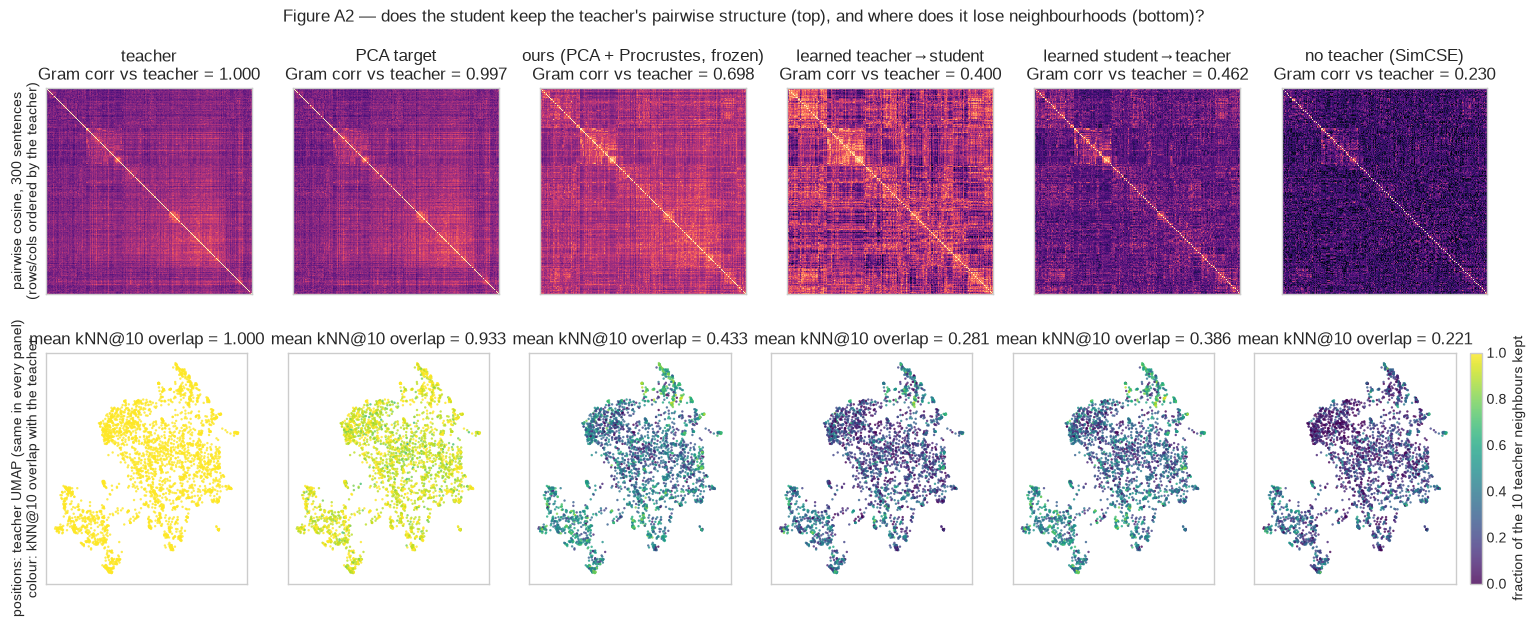

,panel,gram_corr_vs_teacher,knn10_vs_teacher,share_below_0.3
0,teacher,1.0000,1.0000,0.0000
1,PCA target,0.9974,0.9327,0.0000
2,"ours (PCA + Procrustes, frozen)",0.6983,0.4330,0.2023
3,learned teacher→student,0.4003,0.2811,0.4833
4,learned student→teacher,0.4622,0.3860,0.2723
5,no teacher (SimCSE),0.2296,0.2211,0.6130


Created archive: /content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384_100k_dedup_20260829-232415_light.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 11. Figure A2 — hai hình "nhìn là thấy" geometry được thừa kế, cả hai bất biến xoay và không so chéo hai không gian khác chiều:
#   hàng trên : Gram heatmap (cosine từng cặp) của ~300 câu, CÙNG thứ tự lấy từ hierarchical clustering trên teacher
#               -> cùng hoa văn khối = cùng geometry; learned t2s nhoè đều = collapse; no_teacher có khối nhưng ở chỗ khác.
#   hàng dưới : retention map — MỘT layout duy nhất (UMAP của teacher, không thì PCA) dùng cho mọi panel, nên vị trí điểm giống hệt;
#               màu mỗi điểm = kNN@10 overlap của câu đó với teacher trong arm tương ứng (0..1, cùng metric với Table A2)
#               -> thấy Ở ĐÂU trong không gian teacher mỗi arm mất láng giềng; số ghi kèm là mean kNN@10.
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.decomposition import PCA as SkPCA
try:
    import umap
    HAVE_UMAP = True
except Exception:
    HAVE_UMAP = False

HEAT_N, SCAT_N, K_RET = 300, 3000, 10
rng = np.random.default_rng(SEED)
heat_idx = np.sort(rng.choice(AGREE_IDX, size=min(HEAT_N, len(AGREE_IDX)), replace=False))
scat_idx = np.sort(rng.choice(AGREE_IDX, size=min(SCAT_N, len(AGREE_IDX)), replace=False))

views = [("teacher", TEACHER_UNIT), ("PCA target", TARGET_OURS)]
views += [(display_name(b), load_final(SEEDS_OF[b][0])) for b in FIGURE3_BASES if b in SEEDS_OF]

# Thứ tự hàng/cột chung cho heatmap: average-linkage trên cosine của teacher.
teacher_heat = sa.unit(TEACHER[heat_idx]).numpy()
order = leaves_list(linkage(teacher_heat, method="average", metric="cosine"))

# Layout chung cho retention map: 2-D của teacher (chỉ vị trí; màu mới là số đo).
teacher_scat = sa.unit(TEACHER[scat_idx]).numpy()
layout = (umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED).fit_transform(teacher_scat)
          if HAVE_UMAP else SkPCA(n_components=2, random_state=SEED).fit_transform(teacher_scat))
teacher_nb = sa.knn_indices(TEACHER[scat_idx], K_RET)


def per_point_overlap(nb_a, nb_b, k):
    """|N_a(i) ∩ N_b(i)| / k cho từng i (cùng trick sort như sa.knn_overlap, nhưng không lấy mean)."""
    sa_, sb_ = nb_a[:, :k].sort(dim=1).values, nb_b[:, :k].sort(dim=1).values
    both = torch.cat([sa_, sb_], dim=1).sort(dim=1).values
    return ((both[:, 1:] == both[:, :-1]).sum(dim=1).float() / k).numpy()


figA2_rows = []
fig, axes = plt.subplots(2, len(views), figsize=(3.1 * len(views), 6.6), squeeze=False)
for col, (label, emb) in enumerate(views):
    u = sa.unit(emb[heat_idx]).numpy()
    gram = u @ u.T
    gram_corr = sa.gram_correlation(emb[heat_idx], TEACHER[heat_idx], max_rows=HEAT_N, seed=SEED)
    ax = axes[0, col]
    ax.imshow(gram[np.ix_(order, order)], cmap="magma", vmin=-0.25, vmax=1.0, interpolation="nearest")
    ax.set(title=f"{label}\nGram corr vs teacher = {gram_corr:.3f}", xticks=[], yticks=[])
    retained = per_point_overlap(sa.knn_indices(emb[scat_idx], K_RET), teacher_nb, K_RET)
    ax = axes[1, col]
    sc = ax.scatter(layout[:, 0], layout[:, 1], c=retained, cmap="viridis", vmin=0, vmax=1, s=3, alpha=0.8, linewidths=0)
    ax.set(title=f"mean kNN@{K_RET} overlap = {retained.mean():.3f}", xticks=[], yticks=[])
    figA2_rows.append({"panel": label, "gram_corr_vs_teacher": gram_corr, f"knn{K_RET}_vs_teacher": float(retained.mean()),
                       f"share_below_0.3": float((retained < 0.3).mean())})
axes[0, 0].set_ylabel(f"pairwise cosine, {len(heat_idx)} sentences\n(rows/cols ordered by the teacher)")
axes[1, 0].set_ylabel(f"positions: teacher {'UMAP' if HAVE_UMAP else 'PCA'} (same in every panel)\ncolour: kNN@{K_RET} overlap with the teacher")
fig.colorbar(sc, ax=axes[1, :].tolist(), fraction=0.012, pad=0.01, label=f"fraction of the {K_RET} teacher neighbours kept")
fig.suptitle("Figure A2 — does the student keep the teacher's pairwise structure (top), and where does it lose neighbourhoods (bottom)?")
savefig(fig, "figA2_geometry_inheritance_visual.png"); plt.show()
figA2 = pd.DataFrame(figA2_rows)
figA2.to_csv(ANALYSIS_DIR / "figA2_geometry_inheritance_visual.csv", index=False)
display(figA2.style.format(precision=4, na_rep="-"))

import shutil
ARCHIVE_DIR = RUN_ROOT.parent / f"{RUN_NAME}_light"
if ARCHIVE_DIR.exists():
    shutil.rmtree(ARCHIVE_DIR)
for path in RUN_ROOT.rglob("*"):
    if path.is_dir() or "weights" in path.parts or path.name.startswith("checkpoint_epoch_") or path.name == "best_model.pt":
        continue
    target = ARCHIVE_DIR / path.relative_to(RUN_ROOT)
    target.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(path, target)
archive_path = shutil.make_archive(str(ARCHIVE_DIR), "zip", root_dir=ARCHIVE_DIR)
shutil.rmtree(ARCHIVE_DIR)
print(f"Created archive: {archive_path}")
if IN_COLAB and not SAVE_TO_GOOGLE_DRIVE:
    from google.colab import files
    files.download(archive_path)


In [ ]:
from google.colab import files

files.download(
    "/content/embedding-kd/runs/audit_qwen3_0.6b_to_minilm_h384.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>